# Telecom X - Análisis de Evasión de Clientes (Churn)

En este proyecto se analizarán datos de clientes de Telecom X con el objetivo de identificar patrones asociados a la evasión churn.  
El análisis incluye procesos de extracción, transformación y exploración de datos para obtener insights que ayuden a mejorar la retención de clientes.

In [75]:
#Importar librerías
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

# configuración visual
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.dpi"] = 120

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Extracción de datos

En esta etapa cargamos los datos desde la API proporcionada en el challenge.
Los datos están en formato JSON y contienen información sobre clientes,
servicios contratados y estado de evasión.

In [76]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df_raw = pd.read_json(url)
df_raw.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## Exploración inicial del dataset

Analizamos la estructura del dataset para entender su tamaño, columnas y tipos de datos.

In [77]:
df_raw.shape

(7267, 6)

In [78]:
df_raw.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

## Transformación de datos

El archivo JSON contiene estructuras anidadas.  
Para facilitar el análisis convertimos esas estructuras en columnas utilizando `json_normalize`.

In [79]:
df = pd.json_normalize(df_raw.to_dict(orient="records"))

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

## Verificación de inconsistencias

En esta etapa buscamos valores nulos, duplicados o errores de formato que puedan afectar el análisis.

In [81]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [82]:
df.duplicated().sum()

np.int64(0)

## Limpieza de datos

Se corrigen inconsistencias detectadas como valores vacíos y tipos de datos incorrectos.

In [83]:
df = df.replace(r'^\s*$', np.nan, regex=True)

## Análisis descriptivo

Calculamos métricas básicas para comprender el comportamiento general de los datos.

In [84]:
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


## Distribución de evasión

Analizamos cuántos clientes cancelaron el servicio frente a los que permanecen.

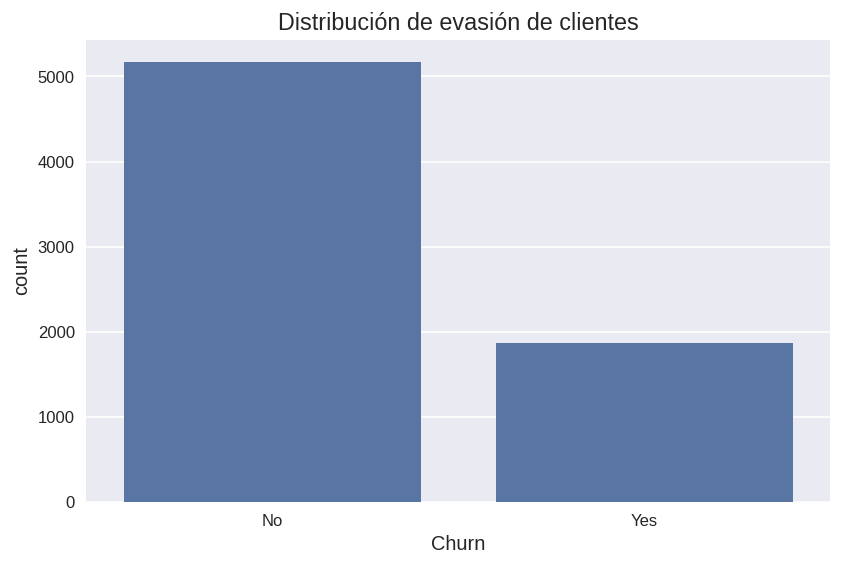

In [85]:
sns.countplot(data=df, x="Churn")

plt.title("Distribución de evasión de clientes")

plt.show()

## Evasión por variables categóricas

Se analiza cómo se distribuye el churn según características de los clientes
como tipo de contrato, método de pago o tipo de servicio.


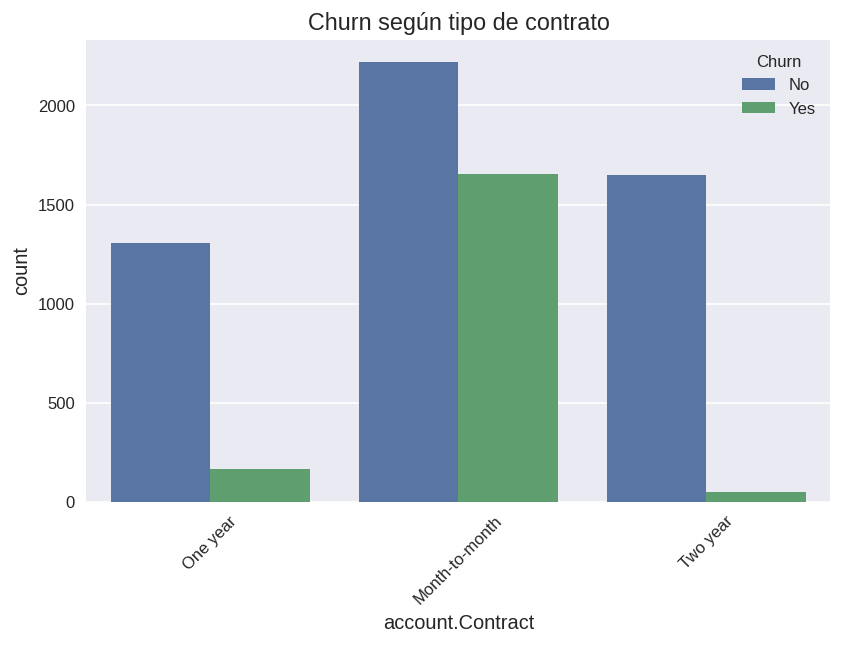

In [86]:
sns.countplot(data=df, x="account.Contract", hue="Churn")

plt.title("Churn según tipo de contrato")

plt.xticks(rotation=45)

plt.show()

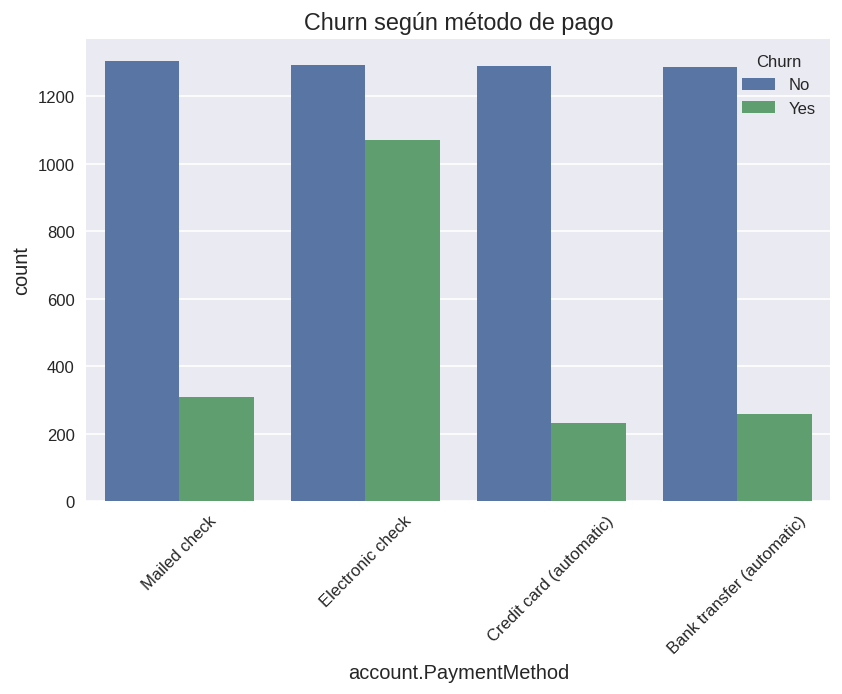

In [87]:
sns.countplot(data=df, x="account.PaymentMethod", hue="Churn")

plt.title("Churn según método de pago")
plt.xticks(rotation=45)
plt.show()

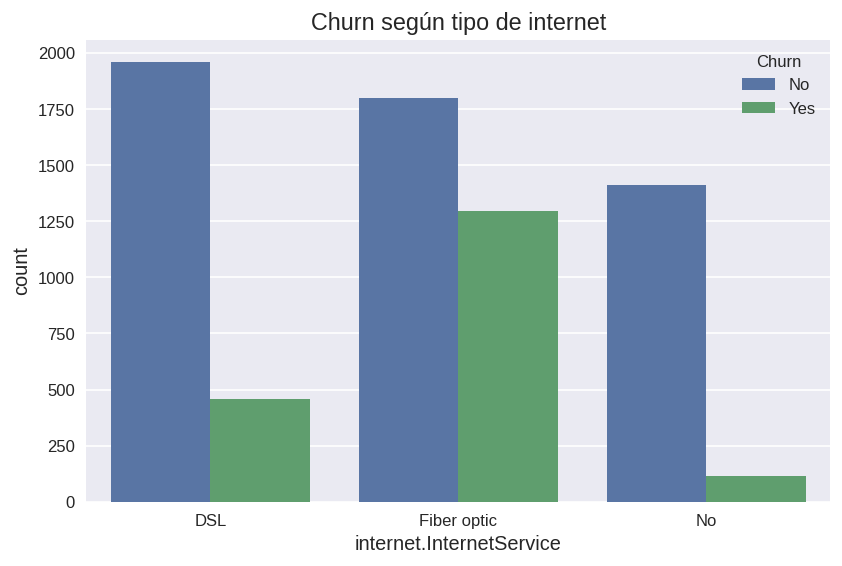

In [88]:
sns.countplot(data=df, x="internet.InternetService", hue="Churn")

plt.title("Churn según tipo de internet")
plt.show()

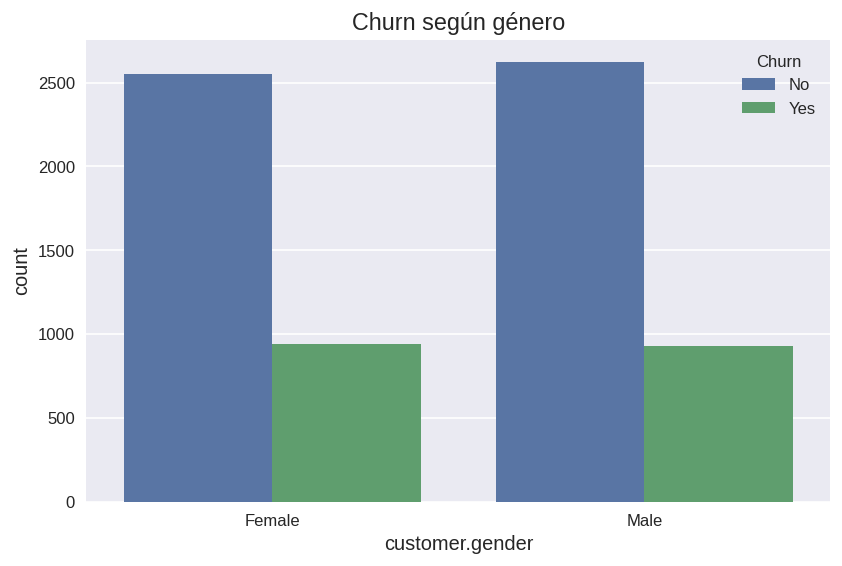

In [89]:
sns.countplot(data=df, x="customer.gender", hue="Churn")

plt.title("Churn según género")
plt.show()

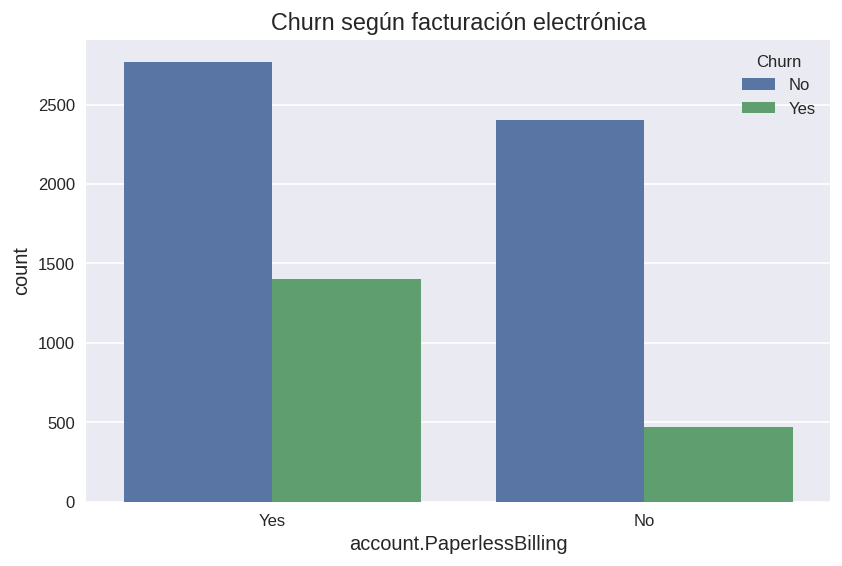

In [90]:
sns.countplot(data=df, x="account.PaperlessBilling", hue="Churn")

plt.title("Churn según facturación electrónica")
plt.show()

## Variables numéricas y churn

Analizamos cómo se distribuyen variables como el gasto mensual
o la antigüedad del cliente según el churn.

<Axes: xlabel='Churn', ylabel='customer.tenure'>

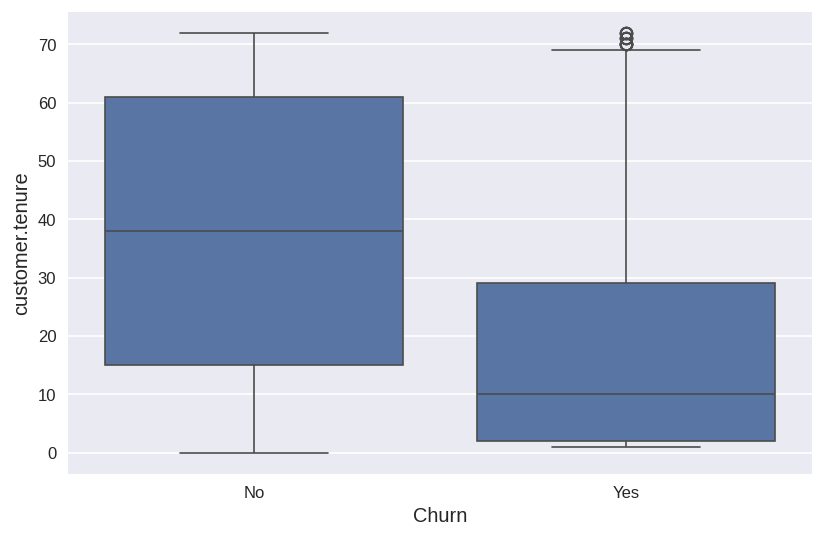

In [91]:
sns.boxplot(data=df, x="Churn", y="customer.tenure")

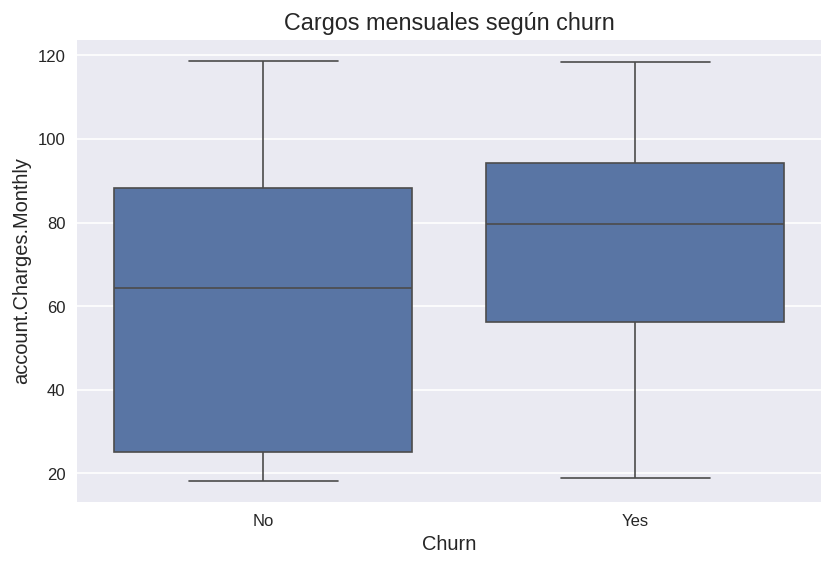

In [92]:
sns.boxplot(data=df, x="Churn", y="account.Charges.Monthly")

plt.title("Cargos mensuales según churn")

plt.show()

In [93]:
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

<Axes: xlabel='Churn', ylabel='account.Charges.Total'>

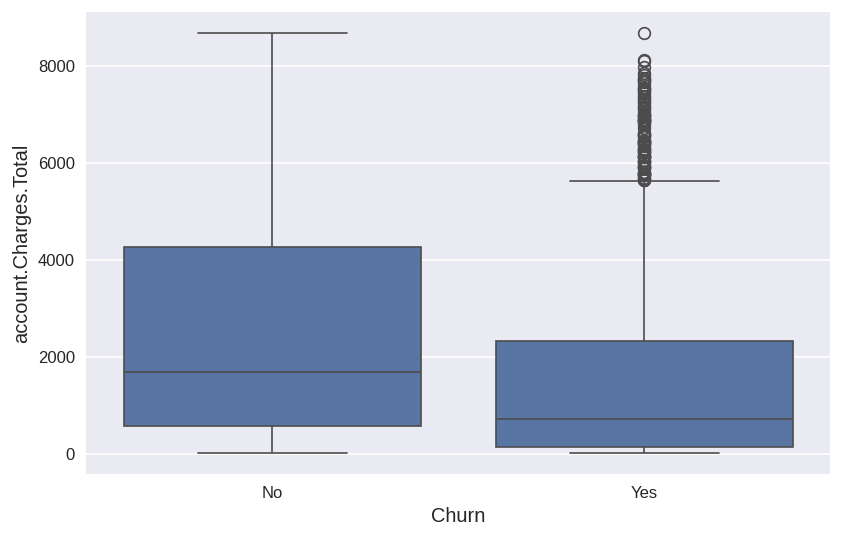

In [94]:
sns.boxplot(data=df, x="Churn", y="account.Charges.Total")

## Conclusiones

El análisis exploratorio permitió identificar patrones relevantes en la evasión de clientes.

Se observó que algunos factores presentan mayor relación con el churn, especialmente el tipo de contrato, la antigüedad del cliente y los cargos mensuales.

Los clientes con contratos mensuales tienden a presentar mayores tasas de cancelación en comparación con aquellos con contratos de mayor duración. Además, los clientes con menor antigüedad muestran mayor probabilidad de abandonar el servicio.

Estos hallazgos pueden servir como base para desarrollar modelos predictivos de churn, permitiendo anticipar la cancelación de clientes y tomar medidas preventivas.

## Sugerencias

- Analizar estrategias de retención para clientes con contratos mensuales, ya que, presentan mayor probabilidad de evasión
- Diseñar incentivos para aumentar la permanencia de clientes nuevos.
- Evaluar mejoras en los planes con cargos mensuales elevados.
- Implementar modelos predictivos de churn para anticipar cancelaciones.